# Curso: Redes Neurais para Processamento de Linguagem Natural

Prof. [Denilson Alves Pereira](https://sites.google.com/ufla.br/denilsonpereira) <br>
Departamento de Ciência da Computação (DCC) <br>
Instituto de Ciências Exatas e Tecnológicas (ICET) <br> 
Universidade Federal de Lavras (UFLA)

## Exemplos de Aplicações em Processamento de Linguagem Natural

Objetivo: apresentar exemplos de aplicações em PLN, bem como introduzir a plataforma Hugging Face.

Você vai aprender a:
- Usar as bibliotecas da plataforma Hugging Face para PLN
- Usar modelos de linguagem pré-treinados para aplicações de PLN
- Criar as seguintes aplicações em PLN: classificação de sentimentos, classificação de textos, geração de textos, preenchimento de palavras mascaradas, reconhecimento de entidades nomeadas, extração de respostas para perguntas, sumarização e tradução de textos.

Referências: <br>
https://huggingface.co/ <br>
https://huggingface.co/learn/nlp-course/chapter1/3?fw=pt

Versão: Outubro, 2023

## Plataforma Hugging Face

Hugging Face (https://huggingface.co/) é uma plataforma de recursos para aplicações em aprendizagem de máquina. É uma plataforma colaborativa, onde membros da comunidade disponibilizam modelos, datasets e aplicações de Inteligência Artificial.

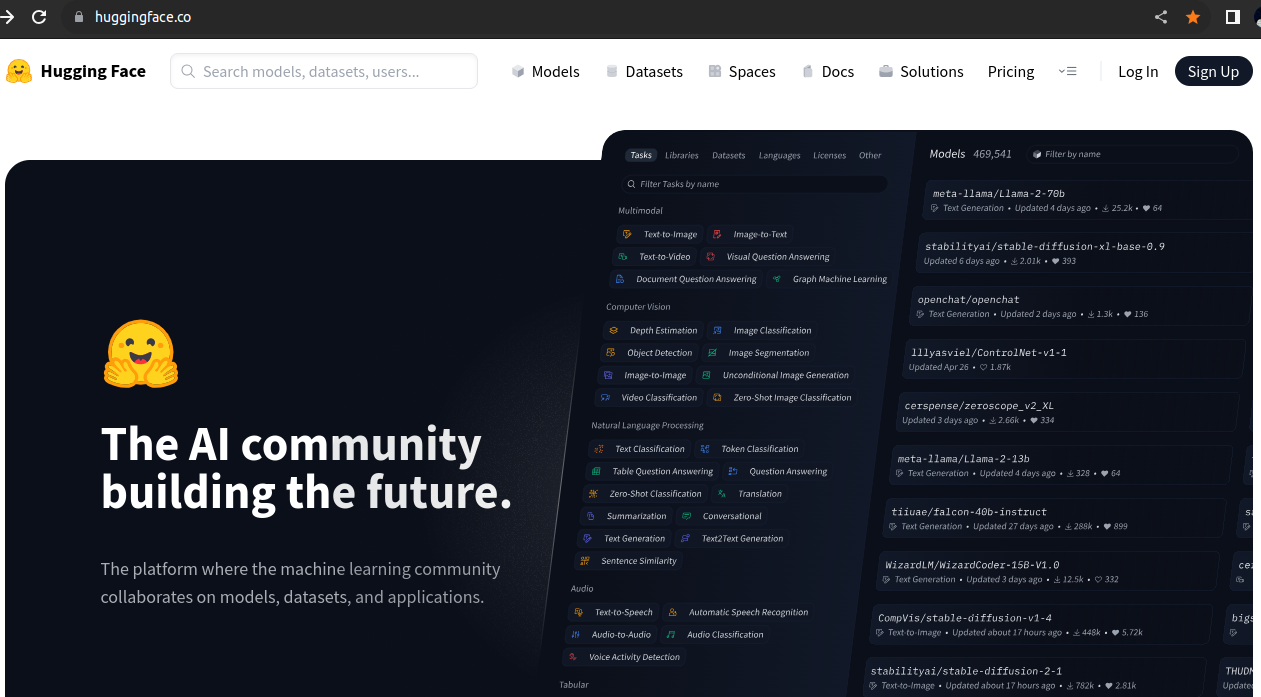

Os códidos a seguir fazem parte de um curso da plataforma Hugging Face sobre PLN, e estão disponíveis em https://huggingface.co/learn/nlp-course/chapter1/3?fw=pt

## Transformers

Modelos baseados na arquitetura Transformer são usados para resolver diversos tipos de tarefas de PLN.

A biblioteca Transformers 🤗 do Hugging Face (https://github.com/huggingface/transformers) fornece as funcionalidades para você criar e usar modelos compartilhados. O Hub de Modelos contém milhares de modelos pré-treinados que você pode fazer o download e usar. E você pode também fazer o upload de seus próprios modelos para o Hub.

O objeto mais básico da biblioteca Transformer 🤗 é a função pipeline(). Ela conecta um modelo com seus passos de pré-processamento e pós-processamento necessários, permitindo-nos diretamente entrar com um texto e obter uma resposta inteligível.

In [1]:
# Instala as bibliotecas Transformer, Datasets e Evaluate
#!pip install datasets evaluate transformers[sentencepiece]

## Classificação de Sentimentos

Dado um texto de entrada, retorna o sentimento expresso nele. Nesse caso, é um problema de classificação de texto, com as classes: Positivo e Negativo.

In [2]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")

# classifica a sentença retornando sua classe (positivo ou negativo) e uma pontuação (score) de confiança na classificação
classifier("I've been waiting for a HuggingFace course my whole life.")

2024-02-22 15:51:38.920014: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-02-22 15:51:39.388217: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-22 15:51:39.388328: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-22 15:51:39.391734: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-02-22 15:51:39.651110: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: A

[{'label': 'POSITIVE', 'score': 0.9598048329353333}]

Por *default* (padrão), esse pipeline seleciona um modelo particular pré-treinado e ajustado (*fine-tuned*) para análise de sentimentos na língua inglesa. O modelo é baixado e colocado em cache quando você cria o objeto *classifier*. Se você re-executar o comando, o modelo em cache será usado, sem necessidade de baixar o modelo novamente.

Há três principais passos envolvidos quando você passa algum texto para o pipeline:
- O texto é pré-processado para um formato que o modelo possa entender.
- As entradas pré-processadas são passadas para o modelo.
- As predições do modelo são pós-processadas, para que possam fazer sentido pra você.

In [3]:
# classifica duas sentenças
classifier(
    ["I've been waiting for a HuggingFace course my whole life.", "I hate this so much!"]
)

[{'label': 'POSITIVE', 'score': 0.9598048329353333},
 {'label': 'NEGATIVE', 'score': 0.9994558691978455}]

## Classificação de Texto

Dado um texto de entrada, retorna o rótulo de sua classe. Nesse caso, as classes são: Education, Politics, Business.

#### Zero-shot Classification

Para classificar um texto usando um modelo do tipo 'zero-shot-classification', você não precisa de dados rotulados para treinar ou fazer o ajuste fino (fine-tunig) do modelo. Você apenas especifica em quais classes o texto deve ser classificado. Essa é uma tarefa mais desafiadora e atende um cenário comum em projetos do mundo real, pois rotular textos usualmente consome muito tempo e requer especialistas no domínio.

In [4]:
from transformers import pipeline

classifier = pipeline("zero-shot-classification")
classifier(
    "This is a course about the Transformers library",
    candidate_labels=["education", "politics", "business"],
)

No model was supplied, defaulted to facebook/bart-large-mnli and revision c626438 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.


{'sequence': 'This is a course about the Transformers library',
 'labels': ['education', 'business', 'politics'],
 'scores': [0.844599187374115, 0.11197397857904434, 0.043426867574453354]}

## Geração de Texto

Na tarefa de geração de texto, você fornece um texto inicial (*prompt*) e o modelo automaticamente completa esse texto, gerando o restante das palavras. A geração de texto envolve aleatoriedade, assim, é normal você não obter o mesmo resultado se executar mais de uma vez.

In [5]:
from transformers import pipeline

generator = pipeline("text-generation")
generator("In this course, we will teach you how to")

No model was supplied, defaulted to gpt2 and revision 6c0e608 (https://huggingface.co/gpt2).
Using a pipeline without specifying a model name and revision in production is not recommended.
/home/denilson/pln/lib/python3.10/site-packages/transformers/utils/generic.py:311: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': 'In this course, we will teach you how to recognize the voice of the great Lord Christ. In this way, I have discovered that it is easier than ever ever to recognize his words. It is almost impossible for me to speak when I speak in'}]

Você pode controlar quantas sequências diferentes são geradas com o argumento 'num_return_sequences' e o tamanho total do texto de saída com o argumento 'max_length'.

Você pode também escolher o modelo a ser usado, neste caso, o 'pierreguillou/gpt2-small-portuguese'. Este é um modelo baseado no GPT-2 (https://huggingface.co/pierreguillou/gpt2-small-portuguese).

In [6]:
from transformers import pipeline

generator = pipeline("text-generation", model="pierreguillou/gpt2-small-portuguese")
generator(
    "Neste curso, nós ensinaremos você a",
    max_length=100,
    num_return_sequences=2,
)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': 'Neste curso, nós ensinaremos você a entender como a experiência é vivida. Na minha experiência como artista em termos de exposição, o que eu realmente tinha era um ponto alto dentro de minha cabeça, que eu não estava preparada para fazer com outra pessoa por muito tempo."\n\n"Thank Me, I\'ll Remember" fez sucesso em todo o país, e chegou a mais de US$1,5 milhão por concerto em Chicago, Michigan, em novembro de 2007.\n\nEm agosto de'},
 {'generated_text': 'Neste curso, nós ensinaremos você a explorar as respostas de todos os possíveis fatores. E nós colocam você em duas áreas que você pode escolher: teoria e realidade. Então, temos o desenvolvimento dos processos sociais (e eufemismos de desenvolvimento do comportamento social), e então nós trabalham em uma aplicação desses desenvolvimentos para obter respostas sobre como podemos chegar a qualquer grau de certeza de que é verdade ou não (ou por causa do que em uma dada situação seja ou não verdade ou não) e, depois 

## Preenchimento de Palavras Mascaradas

A ideia da tarefa de preenchimento de palavras mascaradas (*fill-mask*) é completar os espaços em branco de um dado texto.

O argumento 'top_k' controla quantas possibilidades você quer que sejam mostradas. O modelo preenche a palavra no lugar marcado com \<mask\>, o qual é normalmente referenciado com token mascarado.

In [7]:
from transformers import pipeline

unmasker = pipeline("fill-mask")
unmasker("This course will teach you all about <mask> models.", top_k=2)

No model was supplied, defaulted to distilroberta-base and revision ec58a5b (https://huggingface.co/distilroberta-base).
Using a pipeline without specifying a model name and revision in production is not recommended.
Some weights of the model checkpoint at distilroberta-base were not used when initializing RobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


[{'score': 0.19619794189929962,
  'token': 30412,
  'token_str': ' mathematical',
  'sequence': 'This course will teach you all about mathematical models.'},
 {'score': 0.04052729159593582,
  'token': 38163,
  'token_str': ' computational',
  'sequence': 'This course will teach you all about computational models.'}]

## Reconhecimento de Entidades Nomeadas

O reconhecimento de entidades nomeadas é uma tarefa em que o modelo deve encontrar quais partes do texto de entrada correspondem a entidades, tais como nomes de pessoas, locais e organizações.

No exemplo abaixo, o modelo corretamente identifica que 'João Silva' é uma pessoa (PER), 'Petrobrás' uma organização (ORG) e 'Rio de Janeiro' uma localização (LOC).

A opção 'grouped_entities=True' diz ao pipeline para reagrupar as partes da sentença que correspondem a mesma entidade, permitindo reconhecer nomes compostos por mais de uma palavra (ex: 'João Silva' e 'Rio de Janeiro').

In [8]:
from transformers import pipeline

ner = pipeline("ner", grouped_entities=True, model="Babelscape/wikineural-multilingual-ner")
ner("João Silva trabalha na estatal Petrobrás no Rio de Janeiro.")

/home/denilson/pln/lib/python3.10/site-packages/transformers/pipelines/token_classification.py:169: UserWarning: `grouped_entities` is deprecated and will be removed in version v5.0.0, defaulted to `aggregation_strategy="simple"` instead.
  warnings.warn(


[{'entity_group': 'PER',
  'score': 0.9990405,
  'word': 'João Silva',
  'start': 0,
  'end': 10},
 {'entity_group': 'ORG',
  'score': 0.54515463,
  'word': 'Petrobrás',
  'start': 31,
  'end': 40},
 {'entity_group': 'LOC',
  'score': 0.99964696,
  'word': 'Rio de Janeiro',
  'start': 44,
  'end': 58}]

## Extração de Respostas para Perguntas

A tarefa de extração de resposta para pergunta extrai de um dado contexto a resposta para uma pergunta. Ela não gera a resposta. A geração de resposta é um outro tipo de tarefa que não exige o contexto.

In [9]:
from transformers import pipeline

question_answerer = pipeline("question-answering")
question_answerer(
    question="Where do I work?",
    context="My name is Sylvain and I work at Hugging Face in Brooklyn",
)

No model was supplied, defaulted to distilbert-base-cased-distilled-squad and revision 626af31 (https://huggingface.co/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.


{'score': 0.6949766278266907, 'start': 33, 'end': 45, 'answer': 'Hugging Face'}

## Sumarização de Texto

Sumarização é a tarefa que reduz um texto para uma forma mais curta mantendo todos (ou a maioria) dos aspectos importantes referenciados no texto. Você pode especificar o tamanho máximo ou o mínimo para o texto resultante usando os argumentos 'max_length' e 'min_length'.

In [10]:
from transformers import pipeline

summarizer = pipeline("summarization")
summarizer(
    """
    America has changed dramatically during recent years. Not only has the number of
    graduates in traditional engineering disciplines such as mechanical, civil,
    electrical, chemical, and aeronautical engineering declined, but in most of
    the premier American universities engineering curricula now concentrate on
    and encourage largely the study of engineering science. As a result, there
    are declining offerings in engineering subjects dealing with infrastructure,
    the environment, and related issues, and greater concentration on high
    technology subjects, largely supporting increasingly complex scientific
    developments. While the latter is important, it should not be at the expense
    of more traditional engineering.

    Rapidly developing economies such as China and India, as well as other
    industrial countries in Europe and Asia, continue to encourage and advance
    the teaching of engineering. Both China and India, respectively, graduate
    six and eight times as many traditional engineers as does the United States.
    Other industrial countries at minimum maintain their output, while America
    suffers an increasingly serious decline in the number of engineering graduates
    and a lack of well-educated engineers.
"""
)

No model was supplied, defaulted to sshleifer/distilbart-cnn-12-6 and revision a4f8f3e (https://huggingface.co/sshleifer/distilbart-cnn-12-6).
Using a pipeline without specifying a model name and revision in production is not recommended.


[{'summary_text': ' The number of engineering graduates in the United States has declined in recent years . China and India graduate six and eight times as many traditional engineers as the U.S. does . Rapidly developing economies such as China continue to encourage and advance the teaching of engineering . There are declining offerings in engineering subjects dealing with infrastructure, infrastructure, the environment, and related issues .'}]

## Tradução de Texto

Para a tarefa de tradução, você deve fornecer um modelo para um par de linguagem, tal como 'Helsinki-NLP/opus-mt-mul-en' (https://huggingface.co/Helsinki-NLP/opus-mt-mul-en), que traduz de vários idiomas, incluindo o português, para o inglês.

In [11]:
from transformers import pipeline

translator = pipeline("translation", model="Helsinki-NLP/opus-mt-mul-en")
translator("Este curso é produzido pela Hugging Face.")

/home/denilson/pln/lib/python3.10/site-packages/transformers/models/marian/tokenization_marian.py:197: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


[{'translation_text': 'This course is produced by Hugging Face.'}]

# Fim

Esse notebook apresentou exemplos de aplicações em PLN, por meio da plataforma Hugging Face. O uso de pipelines é principalmente para propósitos demonstrativos. Eles foram programados para tarefas específicas e não são capazes de executar variações delas. Neste curso, você vai aprender como as funções do pipeline funcionam e como personalizar o seu comportamento para algumas dessas tarefas.

-------------------------------------------